## Regresion Lineal

In [ ]:
# Grafica
import matplotlib.pyplot as plt

x = [2, 4, 6, 8, 10, 1, 5, 7, 9, 11]
y = [55, 63, 72, 81, 88, 50, 68, 76, 85, 91]

plt.scatter(x, y)
plt.title("Horas de estudio vs Calificación")
plt.xlabel("Horas de estudio (H)")
plt.ylabel("Calificacion")
plt.grid()


In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

# datos

x = [2, 4, 6, 8, 10, 1, 5, 7, 9, 11]
y = [55, 63, 72, 81, 88, 50, 68, 76, 85, 91]

# Convertir los datos en arrays

X = np.array(x).reshape(-1, 1)
Y = np.array(y)

# Crear y entrenar el modelo

modelo = LinearRegression()
modelo.fit(X, Y)

# obtener parametros del modelo

b = modelo.intercept_
m = modelo.coef_

y_predic = modelo.predict(X)
print(y_predic)
print(Y)

# Calcular metricas

r2 = r2_score(Y, y_predic)
rmse = mean_squared_error(Y, y_predic) ** (1 / 2)

print("El valor del r2 es : ", r2)  # un buen resultado es por encima de 0.8
print("El valor del rmse es : ", rmse)  # que tanto se equivoa el modelo en las unidades de y



In [ ]:
# Crear visualización del modelo

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='blue', s=100, label="Datos reales")
plt.plot(x, y_predic, color="red", linewidth=2, label=f"Regresion lineal (R2 = {r2:.2f})")

plt.title("Regresion lineal: Prediccion de calificacion basado en horas de estudio")
plt.xlabel("Horas de estudio (H)")
plt.ylabel("Calificación")
plt.grid()
plt.legend()
plt.savefig("regresion.png")


In [ ]:
horas_karla = 12

calificacion_carla = m[0] * horas_karla + b

print(f"La calificacion de Karla es {calificacion_carla:.2f} ")

In [ ]:
horas_gloria = 3

calificacion_gloria = m[0] * horas_gloria + b

print(f"La calificacion de Gloria es {calificacion_gloria:.2f} ")

## Regresion Multinomial

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import seaborn as sns


In [2]:
dataP = sns.load_dataset("penguins")
dataP

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [3]:
dataP.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [4]:
dataP.shape

(344, 7)

In [5]:
print(dataP.isnull().sum())

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


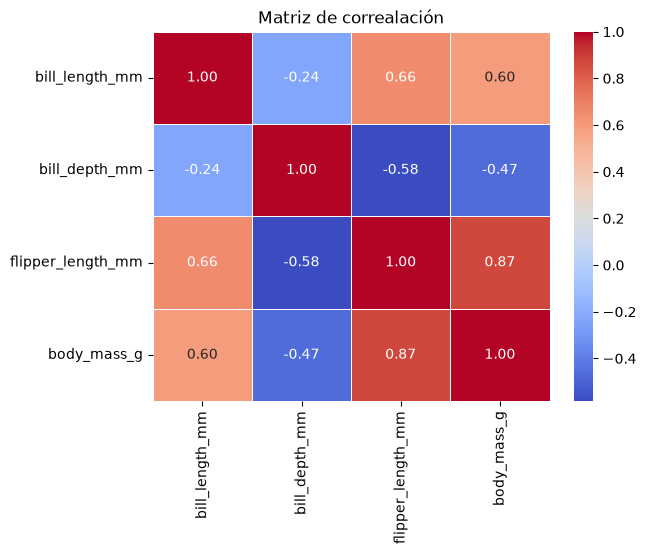

In [6]:
# Matriz de correlacion

corr_matriz = dataP.corr(numeric_only=True)

sns.heatmap(corr_matriz, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de correalación")
plt.show()


In [7]:
dataP = dataP.dropna()

x = dataP[["bill_length_mm", "flipper_length_mm"]]
y = dataP["body_mass_g"]

# 70% entrenamiento
# 30% prueba

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)



In [8]:
model = LinearRegression()
model.fit(x_train, y_train)
y_predict = model.predict(x_test)
r2 = r2_score(y_test, y_predict)
rms = mean_squared_error(y_test, y_predict) ** (1 / 2)

In [9]:
print("Coeficientes del modelo : ", model.coef_)
print("Intercepto : ", model.intercept_)
print(f"r2 del modelo :  {r2:.2f}")
print(f"Error cuadratico medio : {rms:.2f}")

Coeficientes del modelo :  [ 6.13328924 49.72977466]
Intercepto :  -6068.42585873859
r2 del modelo :  0.77
Error cuadratico medio : 372.81


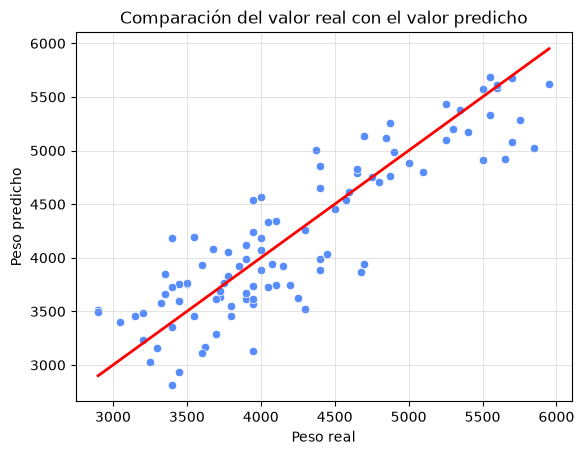

In [10]:
sns.scatterplot(x=y_test, y=y_predict)
lim = [y_test.min(), y_test.max()]
plt.plot(lim, lim, color="red", linewidth=2)
plt.xlabel("Peso real")
plt.ylabel("Peso predicho")
plt.title("Comparación del valor real con el valor predicho")
plt.grid()
plt.show()



## Regresion Polinomial

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("energia_temperatura.csv")


df.head()

,temperatura_C,consumo_kWh
0,-10.000000,587.450712
1,-9.748744,568.931313
2,-9.497487,571.826891
3,-9.246231,576.164303
4,-8.994975,541.114855


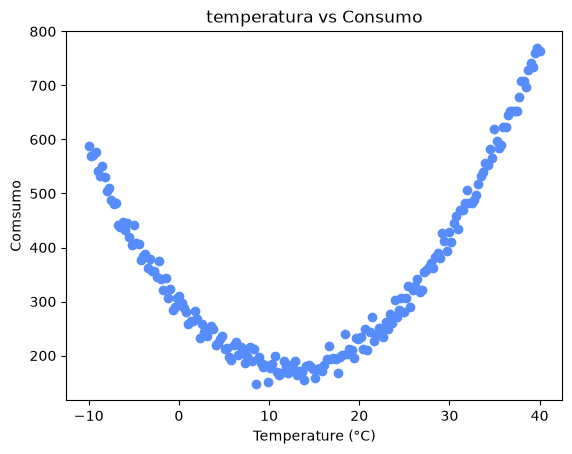

In [20]:
x = df["temperatura_C"]
y = df ["consumo_kWh"]


plt.scatter(x,y)
plt.title("temperatura vs Consumo")
plt.xlabel("Temperature (°C)")
plt.ylabel("Comsumo")
plt.show()

R2: 0.13267914501512224
MSE: 150.89099554729435


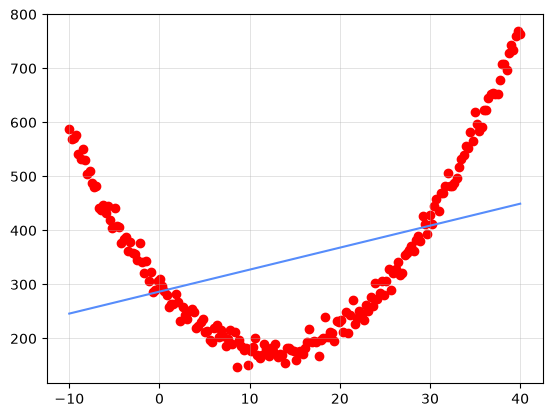

In [16]:
#modelar el ejercicio con una regresio lineal
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error

x= np.array(x).reshape(-1,1)
y= np.array(y)



modelo = LinearRegression()
modelo.fit(x,y)
predic_y = modelo.predict(x)

r2 = r2_score(y,predic_y)
mse = mean_squared_error(y,predic_y)**(1/2)

print("R2:",r2)
print("MSE:",mse)


plt.scatter(x,y,c= "red")
plt.plot(x,predic_y)
plt.grid()


R2: 0.13267914501512224
MSE: 150.89099554729435


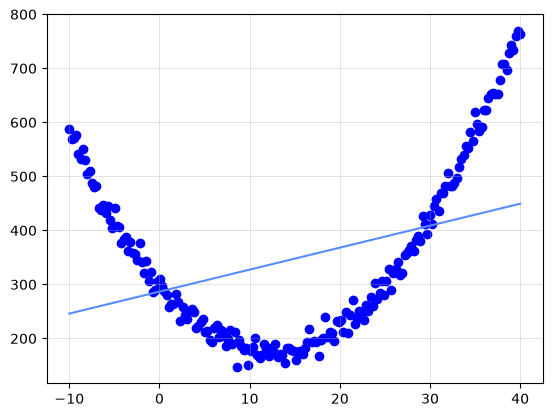

In [17]:
#modelar el ejercicio con una regresio lineal
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error

x= np.array(x).reshape(-1,1)
y= np.array(y)



modelo = LinearRegression()
modelo.fit(x,y)
predic_y = modelo.predict(x)

r2 = r2_score(y,predic_y)
mse = mean_squared_error(y,predic_y)**(1/2)

print("R2:",r2)
print("MSE:",mse)


plt.scatter(x,y,c= "blue")
plt.plot(x,predic_y)
plt.grid()


R2: 0.9926492539031974
MSE: 13.891180045302457


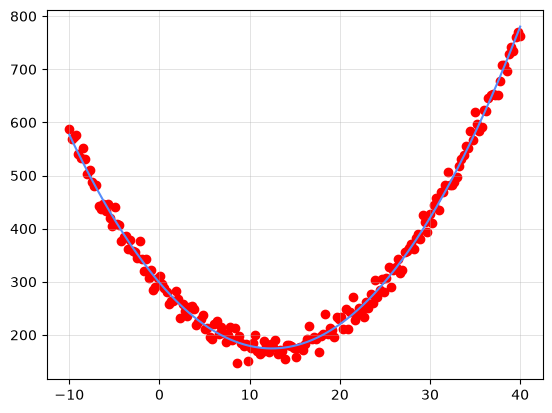

In [18]:
from math import degrees
#implemtar una regresio polinomial

from sklearn.preprocessing import PolynomialFeatures

regre_poli = PolynomialFeatures

regre_poli = PolynomialFeatures(degree=2)
x_poli = regre_poli.fit_transform(x)

modelo2 = LinearRegression()
modelo2.fit(x_poli,y) #potencias de x , son variables de entrada
predic_y2 = modelo2.predict(x_poli)

r2_poli = r2_score(y,predic_y2)
mse_poli = mean_squared_error(y,predic_y2)**(1/2)

print("R2:",r2_poli)
print("MSE:",mse_poli)

plt.scatter(x,y,c= "red")
plt.plot(x,predic_y2)
plt.grid()
#